# 一.决策树

## 1.什么是决策树

## 2.如何进行决策树划分

## 3.决策树的结构

## 4.决策树的三种主要算法

In [1]:
import pandas as pd

# 创建 DataFrame
data = {'算法': ['ID3', 'C4.5', 'CART'],
        '划分标准': ['信息增益', '信息增益率', '基尼系数'],
        '适用情况': ['离散数据', '连续&离散数据', '分类&回归'],
        '优缺点': ['易偏向取值较多的特征', '计算较复杂，处理连续值', '可构建分类树&回归树']}

df = pd.DataFrame(data)

df

,算法,划分标准,适用情况,优缺点
0,ID3,信息增益,离散数据,易偏向取值较多的特征
1,C4.5,信息增益率,连续&离散数据,计算较复杂，处理连续值
2,CART,基尼系数,分类&回归,可构建分类树&回归树


## 5.决策树的构建过程

## 6.决策树的剪枝

## 7. 决策树的应用 

## 8.代码示例

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree


In [3]:
# 加载数据集
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

# 创建决策树模型
# 适用基尼系数作为划分标准，最大深度设为3
clf = DecisionTreeClassifier(criterion="gini", max_depth=3)
# 训练模型
clf.fit(X_train, y_train)

# 预测
y_pred = clf.predict(X_test)

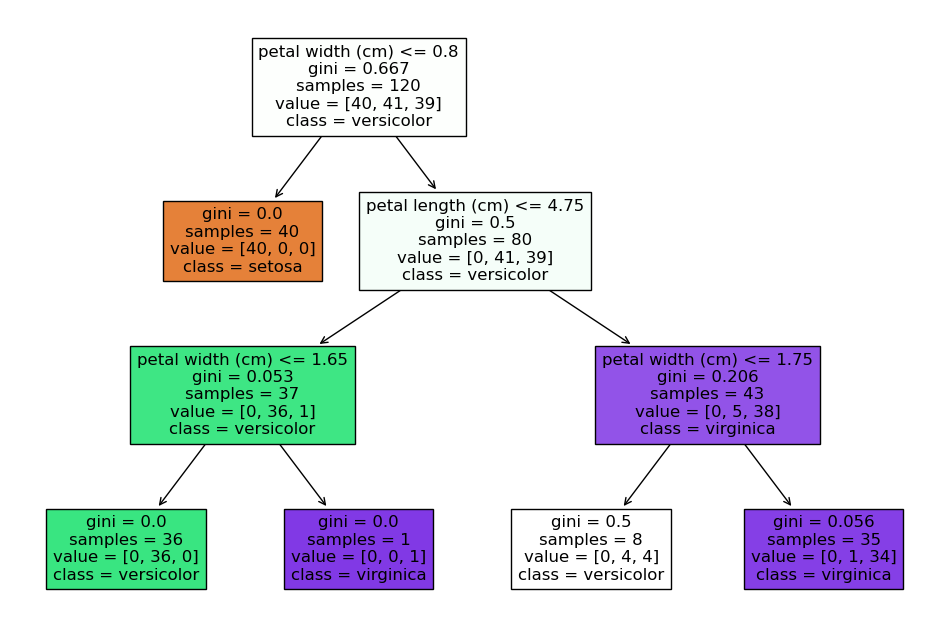

In [4]:
# 可视化决策树
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
tree.plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

## 9. 结论

# 二.信息熵和条件熵

## 1.信息熵

对于一个离散随机变量 X（如分类任务的类别），它可能有 n 个不同的取值（类别），概率分别为 p_1, p_2, …, p_n，则信息熵的计算公式为：

$H(X) = -\sum_{i=1}^{n} p_i \log_2 p_i$

其中：  
	•$H(X)$ 表示随机变量 $X$ 的信息熵  
	•$p_i$ 表示 X 取某个值 $x_i$ 的概率  
    •$\log_2 p_i$ 计算的是该概率的信息量（更小的概率带来更大的信息量）

示例：

(1) 分类任务：样本均匀分布时，熵最大

假设有 100 个样本，类别分布如下：  
	•类别 A：50 个样本（p(A) = 0.5）  
	•类别 B：50 个样本（p(B) = 0.5）  

信息熵计算：  
$H(X) = - (0.5 \log_2 0.5 + 0.5 \log_2 0.5)
= - (0.5 \times (-1) + 0.5 \times (-1)) = 1$

熵值 = 1，比特（二进制信息量）

(2)分类任务：一个类别占绝对优势，熵最小

假设：  
	•类别 A：95 个样本（p(A) = 0.95）  
	•类别 B：5 个样本（p(B) = 0.05）  

信息熵计算：  
$H(X) = - (0.95 \log_2 0.95 + 0.05 \log_2 0.05) \approx 0.286$. 

熵值低，表示数据的确定性高

## 2.条件熵

条件熵衡量的是在已知另一个变量的情况下，原始数据的不确定性。  

公式：  

$H(Y | X) = \sum_{i=1}^{n} P(x_i) H(Y | X = x_i)$. 

其中：  
	•$H(Y | X)$ 表示在已知变量 $X$ 后，$Y$ 仍然存在的不确定性  
	•$H(Y | X = x_i)$ 表示在某个特定 $X$ 取值下的熵  
	•$P(x_i)$ 是 $X$ 取值 $x_i$ 的概率  

In [ ]:
import pandas as pd

# 创建信息熵 vs. 条件熵 对比表格
data = {
    "概念": ["信息熵 (Entropy)", "条件熵 (Conditional Entropy)"],
    "定义": ["衡量数据本身的不确定性，熵越大，数据越随机。",
        "在已知一个变量 X 的情况下，目标变量 Y 的不确定性。"],
    "表示数据的内容": ["整体数据的随机性，是否容易预测。",
        "Y 在不同 X 下的不确定性，衡量 X 对 Y 的影响。"],
    "应用场景": ["衡量数据的纯度，例如决策树的 ID3 算法。",
        "用于计算信息增益，选择最优分裂特征。"]}

df_entropy = pd.DataFrame(data)

# 显示 DataFrame
print(df_entropy)

## 4. 例子：用决策树解释信息熵和条件熵

In [ ]:
df = {'天气(X)': ['晴天', '阴天', '雨天', '晴天', '晴天', '阴天', '雨天', '阴天'],
      '运动(Y)': ['是', '是', '否', '是', '否', '是', '否', '是', ]}
df = pd.DataFrame(df)
df

信息熵：计算“是否运动” (Y) 的不确定性：  
	运动 = 是：5 次  
	运动 = 否：3 次  
	$$H(Y) = -(\frac{5}{8} \log_2 \frac{5}{8} + \frac{3}{8} \log_2 \frac{3}{8}) = 0.954$$

条件熵：如果我们根据 天气 X 来分组（“晴天”、“阴天”、“雨天”），计算运动 Y 的不确定性：  
	•H(Y | 天气) 计算不同天气情况下，Y 的不确定性是否减少。
    
    晴天（3 次）：“是” 2 次，“否” 1 次  
$$H(Y | 晴天) = -\left(\frac{2}{3} \log_2 \frac{2}{3} + \frac{1}{3} \log_2 \frac{1}{3}\right)= -\left(0.666 \times (-0.585) + 0.333 \times (-1.585)\right)= 0.918$$  
    
    阴天（3 次）：“是” 3 次，“否” 0 次
$$H(Y | 阴天) = -\left(1.0 \log_2 1.0 + 0.0 \log_2 0.0 \right) = 0$$  
    
	雨天（2 次）：“是” 0 次，“否” 2 次  
$$H(Y | 雨天) = -\left(1.0 \log_2 1.0 + 0.0 \log_2 0.0 \right) = 0$$
    
$H(Y | X) = \sum_{i=1}^{n} P(X_i) H(Y | X = X_i)$  
其中：  
	$P(X_i)$ 是天气 $X$ 为 $X_i$ 的概率。  
	$H(Y | X = X_i)$ 是在天气为 $X_i$ 时，运动 $Y$ 的熵。  


决策树就是通过条件熵来判断是否需要分裂某个特征！  
	•如果一个特征可以大大降低条件熵，就选择它作为决策节点。

## 5. 信息熵 & 条件熵 在机器学习中的应用

#### 结论

#### 1.信息熵 衡量数据的不确定性，熵越大，数据越随机。
#### 2.条件熵 衡量在已知一个变量的情况下，另一个变量的剩余不确定性。
#### 3.决策树、特征选择、信息增益等机器学习算法都依赖于熵的概念。


In [ ]:
信息增益、信息增益率、基尼系数的计算
ID3、C4.5、CART 具体如何构建决策树

# 三.信息增益、信息增益率、基尼系数的计算

## 1. 信息增益（Information Gain, IG）

定义：信息增益衡量在给定特征 X 的情况下，目标变量 Y 的不确定性（熵）减少了多少。

计算公式

$$IG(Y, X) = H(Y) - H(Y | X)$$
其中：  
	•H(Y) 是 原始数据集 Y 的信息熵，表示总体的不确定性。  
	•H(Y | X) 是 在特征 X 已知的情况下，Y 的信息熵（条件熵）。  

In [ ]:
df = {'天气(X)': ['晴天', '阴天', '雨天', '晴天', '晴天', '阴天', '雨天', '阴天'],
      '运动(Y)': ['是', '是', '否', '是', '否', '是', '否', '是', ]}
df = pd.DataFrame(df)
df

(1) 计算 $H(Y)$

运动 Y 的概率：  
	·$P(\text{是}) = \frac{5}{8}$  
	·$P(\text{否}) = \frac{3}{8}$

$$H(Y) = - \left( \frac{5}{8} \log_2 \frac{5}{8} + \frac{3}{8} \log_2 \frac{3}{8} \right)
= - (0.625 \times -0.678 + 0.375 \times -1.415)
= 0.954$$

(2) 计算 $H(Y | X)$

假设 天气（X） 有三种情况：  
	•晴天（3 次）：“是” 2 次，“否” 1 次  
	•阴天（3 次）：“是” 3 次，“否” 0 次  
	•雨天（2 次）：“是” 0 次，“否” 2 次  

计算：  
$$H(Y | \text{晴天}) = - \left(\frac{2}{3} \log_2 \frac{2}{3} + \frac{1}{3} \log_2 \frac{1}{3} \right) = 0.918$$  
$$H(Y | \text{阴天}) = - \left(1.0 \log_2 1.0 + 0.0 \log_2 0.0\right) = 0$$  
$$H(Y | \text{雨天}) = - \left(1.0 \log_2 1.0 + 0.0 \log_2 0.0\right) = 0$$

条件熵：  
$$H(Y | X) = \frac{3}{8} \times 0.918 + \frac{3}{8} \times 0 + \frac{2}{8} \times 0 = 0.344$$

(3) 计算信息增益

$$IG(Y, X) = H(Y) - H(Y | X) = 0.954 - 0.344 = 0.61$$

结论：天气 X 作为特征可以减少 0.61 的熵，因此它有助于分类。

## 2. 信息增益率（Gain Ratio, GR）

定义：信息增益率在信息增益的基础上，惩罚类别数较多的特征，防止 ID3 偏向于取值多的特征。

计算公式  

$$GR(Y, X) = \frac{IG(Y, X)}{H(X)}$$
其中：
$$H(X) = - \sum P(X_i) \log_2 P(X_i)$$
是 特征 $X$ 的信息熵。

信息增益率的改进：  
	•ID3 的问题：容易选择取值较多的特征（如 “姓名” 可能对分类无用，但每个人的名字不同，导致信息熵较低）。  
	•C4.5 解决方案：引入 归一化因子 H(X)，使得选择分裂特征时更加均衡。  

## 3. 基尼系数（Gini Index）

定义：基尼系数衡量数据的不纯度，用于 CART（分类与回归树）。

计算公式

$$Gini(Y) = 1 - \sum_{i=1}^{n} p_i^2$$
其中：  
	•$p_i$ 是类别 $i$ 的概率

基尼系数 vs. 熵  
	•基尼系数更加计算简单，通常与 ID3 / C4.5 相比计算更快。  
	•熵更加准确，但计算稍复杂。  

In [ ]:
import pandas as pd

# 创建 DataFrame
data = {'算法': ['ID3', 'C4.5', 'CART'],
        '划分标准': ['信息增益', '信息增益率', '基尼系数'],
        '适用情况': ['类别较少的数据集', '解决ID3偏向多值特征问题', '二分类和回归任务']}

df = pd.DataFrame(data)

df

## 四.ID3、C4.5和CART决策树算法

1. ID3（基于信息增益）

步骤  
	1.计算所有特征的信息增益 IG(Y, X)。  
	2.选择信息增益 最大的特征 作为分裂节点。  
	3.递归地对子节点继续分裂，直到：所有样本属于同一类别（叶子节点）；信息增益低于阈值（停止）。  

缺点  
	偏向于取值多的特征（如 “姓名”），导致过拟合。

 2. C4.5（基于信息增益率）

改进点  
	•使用信息增益率 而不是信息增益。  
	•支持连续特征（ID3 只能用于离散特征）。  
	•支持缺失值处理。  

步骤  
	1.计算所有特征的信息增益率 GR(Y, X)。  
	2.选择 信息增益率最大 的特征进行分裂。  

优势  
	•避免 ID3 偏向于类别多的特征。  
	•能处理 连续型数据（如 “年龄”）。  
	•能处理 缺失值。  

3. CART（基于基尼系数）

用于分类和回归  
	•CART 既能做分类（决策树）也能做回归（回归树）。  
	•分类时，使用 基尼指数（Gini Index） 选择特征。  

步骤  
	1.计算所有特征的基尼系数 Gini(Y, X)。  
	2.选择 基尼指数最小 的特征进行分裂。  
	3.递归进行，直到叶子节点。  

优势  
	•可用于 回归问题，不像 ID3 / C4.5 只能用于分类。  
	•生成的是 二叉树，比 ID3 / C4.5 更稳定。  

结论

ID3 适用于离散数据，但容易过拟合（偏向于取值多的特征）。  
C4.5 通过信息增益率改进了 ID3，可处理连续数据。  
CART 采用基尼系数，可用于分类和回归任务，是最广泛使用的决策树算法。  